###  MFCC-Chroma Fusion using a Dual-Channel CNN-LSTM Preprocessing Pipeline

##### Import Statements

In [1]:
import numpy as np
import pandas as pd
import os
import librosa as lb
import soundfile as sf
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt
import zipfile
from collections import defaultdict
import random

from scipy.signal import butter, filtfilt
import librosa as lb
import numpy as np

### 1. Initial Configuration 

##### Defined Parameters

In [2]:
# Target size per class (train only)
TARGET_COUNT = 500                      
SEG_LEN = 3
SR = 4000

##### Paths

In [3]:
# Where the dataset rests
RAW_DATA_DIR = "/home/rithik-tank/Desktop/Auscultate/preprocessing/Respiratory_Sound_Database"

ROOT_DIR = "/home/rithik-tank/Desktop/Auscultate/preprocessing" 

#Save Directories
SEGMENTS_DIR = "outputs/segmentation_outputs/" 
#TEST_SEGMENTS_DIR = "outputs/segmentation_outputs/test_segments" 
#VAL_SEGMENTS_DIR = "outputs/segmentation_outputs/val_segments" 
TRAIN_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/train_segments" 

##### Filters and Normalization

The function `load_audio` essentially loads the different audio clips following a 4000Hz sampling rate and applies butterworth filtering prior to returning the audio file. This function will be used to load the **unsegmented** audio files. 

In [4]:
def butterworth_filter(y, sr, lowcut=50, highcut=1800, order=4):
    nyquist = 0.5 * sr

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, y)

The function `rms_normalize` will be applied to **each segment** aftey they are created and before they are exported to the save directories defined.

In [5]:
def rms_normalize(y, eps=1e-9, min_rms=1e-3):
    rms = np.sqrt(np.mean(y**2) + eps)
    if rms < min_rms:
        return y  # avoid boosting silence
    return y / rms

##### Augmentation

In [6]:
def augment_noise(y, sr=SR):
    return y + np.random.normal(0, 0.005, len(y))

def augment_pitch(y, sr=SR):
    steps = np.random.uniform(-2, 2)
    return lb.effects.pitch_shift(y=y, sr=sr, n_steps=steps)

def augment_speed(y, sr=SR):
    rate = np.random.uniform(0.95, 1.05)
    return lb.effects.time_stretch(y=y, rate=rate)

def augment_gain(y, sr=SR):
    return y * np.random.uniform(0.8, 1.2)



# Python list containing all of the augmentation methods
AUGS = [augment_noise, augment_pitch, augment_speed, augment_gain]

### 2. Creating the Reference Data Frame

In [7]:
# Extracts relevant information from the file name
def get_filename_info(file):
    return file.split("_")

In [8]:
def read_icbhi_metadata(data_dir):

    audio_dir = os.path.join(data_dir, "audio_and_txt_files") # Where all of the audio files are stored in the ICBHI dataset
    diagnosis_path = os.path.join(data_dir, "patient_diagnosis.csv") # The CSV file that maps the PID to a disease within the dataset

    # Read patient diagnoses
    patient_df = pd.read_csv(diagnosis_path, names=["pid", "disease"])
    patient_df.pid = patient_df.pid.astype(int) # DF that holds PID and associated Disease

    # Read all annotation txt files
    txt_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".txt")]) # All of the annotiation files associated with the recordings

    rows = []

    # Iterate through all of the audio file annotations and create a datafram that stores all of the data. 
    # It gets the start, end, crackles, and wheezes annotations from the .txt files 
    #   and the PID from the filename itself and the actual filename too.
    for txt in txt_files:
        file = txt.replace(".txt", "")
        metadata = pd.read_csv(
            os.path.join(audio_dir, txt),
            sep="\t",
            names=["start", "end", "crackles", "wheezes"]
        )
        pid = int(get_filename_info(file)[0]) #  Gets only the first part of the filename which is the PID

        metadata["filename"] = file
        metadata["pid"] = pid

        rows.append(metadata)

    # Combine all annotations
    df = pd.concat(rows)

    # We carry out a merge of the two dataframes using the patient ID so we can have one giant dataframe with all of the necessary information
    df = df.merge(patient_df, on="pid")


    print("The total number of patients within the dataset is exactly", patient_df['pid'].count())
    print("The total number of segments of data within the entire dataset amounts to", df['pid'].count())
    print("After carrying out the join, the total number of segments of data within the entire dataset amounts to", df['pid'].count())


    # We drop disease classes with fewer than 3 unique patients
    counts = df.groupby('disease')['pid'].nunique()
    rare_classes = counts[counts < 3].index.tolist()
    if rare_classes:
        print(f"\nDropping the following rare disease classes with < 3 patients: {rare_classes}")
        df_dropped = df[~df['disease'].isin(rare_classes)].copy()
    else: 
        df_dropped = df['disease']

    
    print("\nThese rare classes have the following number of patients:")
    print(counts[rare_classes])

    print("\nThe Total number of segments that are found among these rare classes amounts to:", df[df['disease'].isin(rare_classes)]['pid'].count())

    print("\nThen, the revised total number of segments after dropping the segments of these rare classes amounts to", df_dropped['pid'].count())

    # We reset the index because of the entries we dropped. We don't want the jumps evident in the dataset because they become confusing later on
    df_dropped = df_dropped.reset_index(drop=True)
    return df_dropped


df = read_icbhi_metadata(RAW_DATA_DIR)
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/df_with_rare_classes_dropped.csv")

The total number of patients within the dataset is exactly 126
The total number of segments of data within the entire dataset amounts to 6898
After carrying out the join, the total number of segments of data within the entire dataset amounts to 6898

Dropping the following rare disease classes with < 3 patients: ['Asthma', 'LRTI']

These rare classes have the following number of patients:
disease
Asthma    1
LRTI      2
Name: pid, dtype: int64

The Total number of segments that are found among these rare classes amounts to: 38

Then, the revised total number of segments after dropping the segments of these rare classes amounts to 6860


### 3. Patient-Level Constrained Stratified Split


This script performs a proper patient-level split for lung sound datasets.

Properties:
- No patient appears in more than one subset
- Guarantees each disease class appears in train, test, unseen (if >= 3 patients)
- 90% development / 10% unseen
- 80/20 train/test inside development
- Reproducible with random seed

Input CSV format (one row per segment or file):
pid, disease, filepath,...

Output:
train_pids.txt
test_pids.txt
val_pids.txt


In [9]:
# CONFIGURATION
UNSEEN_RATIO = 0.10             # 10%
TEST_RATIO_WITHIN_DEV = 0.20    # 20% of development


def constrained_patient_split(pid_df, seed=42):
    rng = np.random.default_rng(seed)

    counts = pid_df.groupby("disease")["pid"].nunique()
    valid_classes = counts.index


    pid_df = pid_df[pid_df["disease"].isin(valid_classes)].copy()
    print("Classes kept:", list(valid_classes))
    print("Classes removed:", list(counts[counts < 3].index))

    # Group the different PIDs by class
    class_groups = {
        cls: pid_df[pid_df["disease"] == cls]["pid"].unique()
        for cls in valid_classes
    }

    train_pool = []
    test_pids = set()
    unseen_pids = set()

    # Ensure that there is a minimum 1 PID per class per subset
    for cls, pids in class_groups.items():
        pids = list(pids)
        rng.shuffle(pids)

        unseen_pids.add(pids[0])
        test_pids.add(pids[1])

        train_pool.extend(pids[2:])

    # Compute target sizes
    all_pids = pid_df["pid"].unique()
    total = len(all_pids)

    target_unseen = int(round(total * UNSEEN_RATIO))

    rng.shuffle(train_pool)

    # Fill unseen
    while len(unseen_pids) < target_unseen and train_pool:
        unseen_pids.add(train_pool.pop())

    # Development pool
    dev_pool = [pid for pid in all_pids if pid not in unseen_pids]

    target_test = int(round(len(dev_pool) * TEST_RATIO_WITHIN_DEV))

    remaining = [pid for pid in dev_pool if pid not in test_pids]
    rng.shuffle(remaining)

    # Fill test
    while len(test_pids) < target_test and remaining:
        test_pids.add(remaining.pop())

    # Rest → train
    train_pids = [pid for pid in dev_pool if pid not in test_pids]

    train_pids  = sorted(map(int, train_pids))
    test_pids   = sorted(map(int, test_pids))
    unseen_pids = sorted(map(int, unseen_pids))

    train_df = pid_df[pid_df['pid'].isin(train_pids)]
    test_df = pid_df[pid_df['pid'].isin(test_pids)]
    val_df = pid_df[pid_df['pid'].isin(unseen_pids)]

    #Outputs only for validation purposes
    os.makedirs("outputs/constrained_patient_split_outputs", exist_ok=True)
    train_df.to_csv("outputs/constrained_patient_split_outputs/train_df_after_split.csv")
    test_df.to_csv("outputs/constrained_patient_split_outputs/test_df_after_split.csv")
    val_df.to_csv("outputs/constrained_patient_split_outputs/val_df_after_split.csv")

    return train_df, test_df, val_df

train_strat, test_strat, val_strat = constrained_patient_split(df)


print("----------------------------------------------------- TRAIN -----------------------------------------------------")
train_pid_per_disease = train_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in train_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

print("----------------------------------------------------- TEST -----------------------------------------------------")
test_pid_per_disease = test_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in test_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

print("----------------------------------------------------- VALIDATION -----------------------------------------------------")
val_pid_per_disease = val_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in val_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

Classes kept: ['Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']
Classes removed: []
----------------------------------------------------- TRAIN -----------------------------------------------------
Bronchiectasis: [111 116 196 201 215]


Bronchiolitis: [149 161 173 216]


COPD: [104 106 107 109 110 112 114 117 118 120 124 128 130 132 133 134 139 141
 142 145 147 151 154 155 156 158 160 162 166 172 174 175 176 178 180 181
 185 186 189 193 198 200 203 205 211 212 213 221 223]


Healthy: [121 125 126 136 143 153 159 171 179 183 184 187 194 202 208 217 224]


Pneumonia: [122 140 191]


URTI: [101 105 129 131 137 148 150 164 165 197 210]


----------------------------------------------------- TEST -----------------------------------------------------
Bronchiectasis: [168]


Bronchiolitis: [206]


COPD: [113 138 157 163 170 177 192 195 204 207 220]


Healthy: [123 127 144 152 182 214]


Pneumonia: [219 226]


URTI: [119]


-------------------------------------------

### 4. Segmentation

**Naming Convention**

The file format that is followed here looks like this:
    101_1b1_Al_sc_Meditron_r-0_s-0.wav

The r-value pertains to the row_index as seen in the cheat_sheet.csv file which was generated earlier.  

To understand why the s-0  is necessary we first take a look at how the data looks per row.

| INDEX | START | END | CRACKLES | WHEEZES | FILENAME | PID | DISEASE |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.036 | 0.579 | 0 | 0 | 101_1b1_Al_sc_Meditron | 101 | URTI |
| 0 | 0.579 | 4.579 | 0 | 0 | 101_1b1_Al_sc_Meditron | 101 | URTI |

Under the first entry we find that the relevant region is only spans 0.543 seconds which is not a problem. But under the second we see that the relevant region spans 4 seconds which is greater than the 3 second segments we intend to follow. As such, the segment will be seperated into n different sub-segments whose unique identifier will be the s-0 keys.

The function `load_audio` essentially loads the different audio clips following a 4000Hz sampling rate and applies butterworth filtering prior to returning the audio file. This function will be used to load the **unsegmented** audio files. 

In [10]:
def load_audio(file_path, sr=SR): # Loads the audio file following the global parameter SAMPLING RATE
    y, sr = lb.load(file_path, sr=sr)
    y = y.astype(np.float32)

    # Butterworth bandpass filter
    y = butterworth_filter(
        y,
        sr,
        lowcut=50,     # remove heart sounds & DC
        highcut=1800,  # remove high-frequency noise
        order=4
    )

    return np.clip(y, -1, 1), sr

In [11]:

def extract_segments(df, data_dir, save_dir, segment_folder):
    audio_dir = os.path.join(data_dir, "audio_and_txt_files")

    seg_folder =os.path.join(save_dir, segment_folder)

    shutil.rmtree(seg_folder, ignore_errors=True)
    os.makedirs(seg_folder)

    segment_list = []
    for row_idx, row in tqdm(df.iterrows(), total=len(df)):

        file = row["filename"]
        start = row["start"]
        end = row["end"]

        # Load the audiofile
        wav_path = os.path.join(audio_dir, file + ".wav")
        y, sr = load_audio(wav_path) # Filtering is applied within the function

        # Compute the exact sample where the audio clip will start and end using the sampling rate.
        s = int(start * SR)
        e = int(end * SR)
        s = max(0, min(s, len(y)))
        e = max(0, min(e, len(y)))

        if e <= s:
            print("Invalid segment window:", file, start, end)

        relevant_region = y[s:e]

        # TIME period in sample will follow the configured SEG_LEN
        seg_samples = SEG_LEN * SR

        # The seg_samples - 1 is add onto the length.
        # This ensures remainders round up instead of down
        n_segments = (len(relevant_region) + seg_samples - 1) // seg_samples

        for i in range(n_segments):
            seg = relevant_region[i * seg_samples:(i + 1) * seg_samples]

            if len(seg) < seg_samples:
                seg = np.pad(seg, (0, seg_samples - len(seg)), mode="constant")


            
            seg = rms_normalize(seg) # Apply RMS normalization
            
            seg_name = f"{file}_r-{row_idx}_s-{i}.wav"
            seg_path = os.path.join(seg_folder, seg_name)
            sf.write(seg_path, seg, SR)

            segment_list.append({
                "segment_file": seg_name,
                "pid": row["pid"],
                "disease": row["disease"],
                "start": start,
                "end": end, 
            })

    return pd.DataFrame(segment_list)

train_segments = extract_segments(train_strat, RAW_DATA_DIR, SEGMENTS_DIR, "train_segments")
test_segments = extract_segments(test_strat, RAW_DATA_DIR, SEGMENTS_DIR, "test_segments")
val_segments = extract_segments(val_strat, RAW_DATA_DIR, SEGMENTS_DIR, "val_segments")

os.makedirs("outputs/segmentation_outputs", exist_ok=True)
train_segments.to_csv("outputs/segmentation_outputs/train_segments.csv")
test_segments.to_csv("outputs/segmentation_outputs/test_segments.csv")
val_segments.to_csv("outputs/segmentation_outputs/val_segments.csv")

#Outputs only for validation purposes
print("\nTrain segments count: ", train_segments['pid'].count())
print("\nTest segments count: ", test_segments['pid'].count())
print("\nVal segments count: ", val_segments['pid'].count())


  0%|          | 0/5300 [00:00<?, ?it/s]/home/rithik-tank/enter/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 501/501 [00:04<00:00, 112.85it/s]


Train segments count:  7054

Test segments count:  1653

Val segments count:  700


### 5. Undersampling and Augmentation. 

**Training Class Only.**

First, we graph the number of segments per disease class to verify how much we have, how much we need to undersample, and how much we need to augment.

##### Segment Distribution

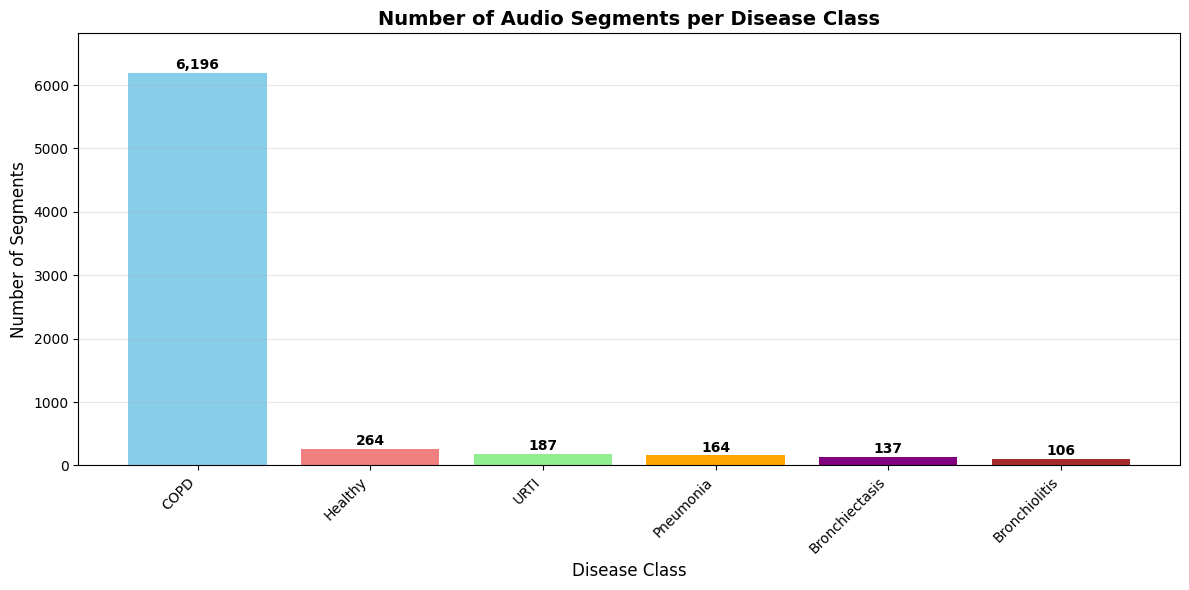

Segment counts per disease:
disease
COPD              6196
Healthy            264
URTI               187
Pneumonia          164
Bronchiectasis     137
Bronchiolitis      106
Name: count, dtype: int64


In [12]:
# Read segments data
seg_df = pd.read_csv('outputs/segmentation_outputs/train_segments.csv')

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

##### Function

In [13]:
def augment_training_set(seg_df, source_dir, save_dir, target_count=TARGET_COUNT, seed = 42, segments_dir = SEGMENTS_DIR):
  rng = random.Random(seed)
  np_rng = np.random.default_rng(seed)

  updated_records = []
  shutil.rmtree(os.path.join(ROOT_DIR,save_dir), ignore_errors=True)
  os.makedirs(os.path.join(ROOT_DIR, save_dir))

  for disease, group in seg_df.groupby("disease"):
    originals = group["segment_file"].tolist()
    pids = group["pid"].tolist()
    files_with_pid = list(zip(originals, pids))
    
    # This carries out the undersampling
    if len(files_with_pid) > target_count:
      # If the data count exists the target number: 
      #   get a subset of the data that is equal to the target count
      files_with_pid = rng.sample(files_with_pid, target_count) # We randomly get the samples
      pd.DataFrame(files_with_pid).to_csv("outputs/augmentation_outputs/df_after_undersampling.csv") 

    # At this point no disease class should have data count > 500  
    count = len(files_with_pid)
    print("The current number of disease", disease, "is equal to", count)
    
    # Copy the original segments to the new augmented folder
    #   We do this by copying all of the files under files_with_pid to the save_dir
    for file, pid in files_with_pid:
      base_file = os.path.basename(file)
      src_path = os.path.join(source_dir, base_file)
      dest_path = os.path.join(save_dir, base_file)
      shutil.copy(src_path,dest_path)
      updated_records.append({
        "segment_file": os.path.join(base_file), 
        "pid": pid, 
        "disease": disease,
      })
#--------------------------------------------------------------------------------------
  # 1212 data points are copied to the train_segments_augmented folder at this point
  # 500 COPD              audio files
  # 257 Healthy           audio files
  # 191 URTI              audio files
  # 114 Pneumonia         audio files
  # 92 Bronchiolitis      audio files
  # 58 Bronchiectasis     audio files
  
  # We now attempt to generate
  # 243 Healthy           audio files
  # 309 URTI              audio files
  # 386 Pneumonia         audio files
  # 408 Bronchiolitis     audio files
  # 442 Bronchiectasis    audio files
#--------------------------------------------------------------------------------------
    for file, pid in files_with_pid:
      base_file = os.path.basename(file)
      src_path = os.path.join(segments_dir, source_dir, base_file)

      dest_path = os.path.join(save_dir, base_file)

      if not os.path.exists(src_path):
          raise FileNotFoundError(f"Original file missing: {src_path}")


    # Get count of needed augmented files
    current_count = len(files_with_pid)
    needed = target_count - current_count
    if needed > 0:
      print(f"\tAugmenting the disease class {disease}. generating a total number of {needed} samples.")

    i = 1
    for _ in range(needed):
      f, pid = rng.choice(files_with_pid) # We use a random file from the list
      y, sr = lb.load(os.path.join(source_dir,f), sr=SR)

      f = os.path.basename(f)
      

      aug_fn = np_rng.choice(AUGS) # Choose a random augmentation function
      y_aug = aug_fn(y, sr) # Apply the augmentation

      base = os.path.basename(f)
      save_name = f"{os.path.splitext(base)[0]}_aug-{disease}-{i}.wav"
      save_path = os.path.join(save_dir, save_name)
      sf.write(save_path, y_aug, sr)

      if not os.path.exists(save_path):
        print("Failed to save:", save_path)

      updated_records.append({
        "segment_file": os.path.join(save_name), 
        "pid": pid, 
        "disease": disease,
      })
      i += 1

  pd.DataFrame(updated_records).to_csv("outputs/augmentation_outputs/train_segments.csv")
  return pd.DataFrame(updated_records)
  
train_augmented = augment_training_set(train_segments, 
    os.path.join(ROOT_DIR, SEGMENTS_DIR, "train_segments"),
    os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
)

The current number of disease Bronchiectasis is equal to 137
	Augmenting the disease class Bronchiectasis. generating a total number of 363 samples.
The current number of disease Bronchiolitis is equal to 106
	Augmenting the disease class Bronchiolitis. generating a total number of 394 samples.
The current number of disease COPD is equal to 500
The current number of disease Healthy is equal to 264
	Augmenting the disease class Healthy. generating a total number of 236 samples.
The current number of disease Pneumonia is equal to 164
	Augmenting the disease class Pneumonia. generating a total number of 336 samples.
The current number of disease URTI is equal to 187
	Augmenting the disease class URTI. generating a total number of 313 samples.


##### Augmented Segment Distribution

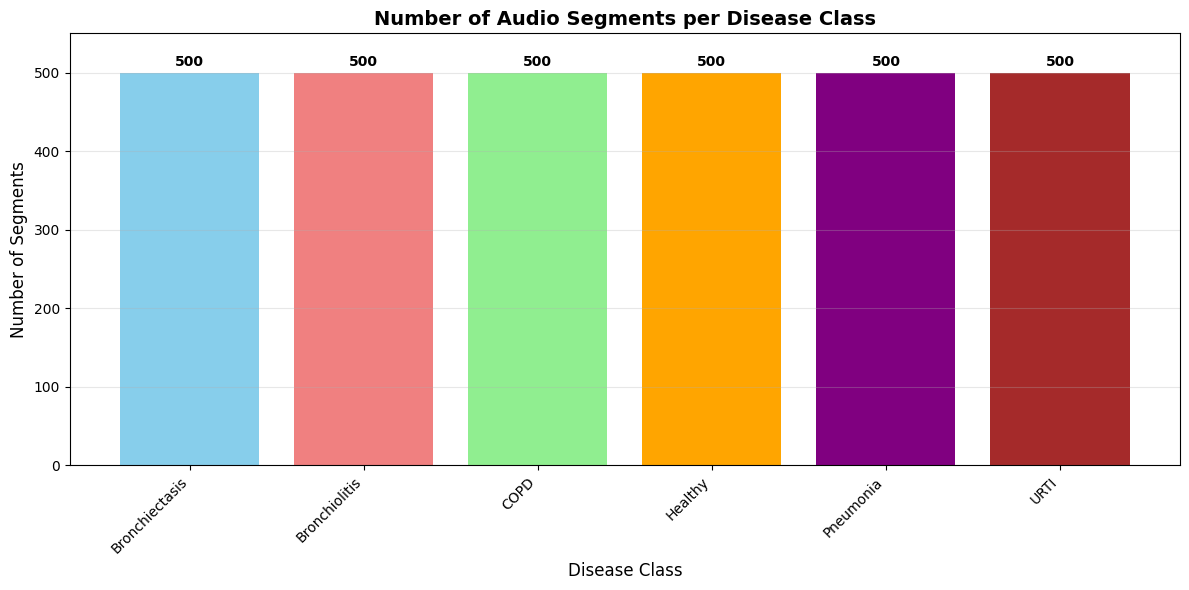

Segment counts per disease:
disease
Bronchiectasis    500
Bronchiolitis     500
COPD              500
Healthy           500
Pneumonia         500
URTI              500
Name: count, dtype: int64


In [14]:
# Read segments data
seg_df = pd.read_csv('outputs/augmentation_outputs/train_segments.csv')

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

In [15]:
shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "test_segments"),
                "../dataset/test-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/test_segments.csv"),
                "../dataset/test_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "val_segments"),
                "../dataset/val-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/val_segments.csv"),
                "../dataset/val_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
                "../dataset/train-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/augmentation_outputs/train_segments.csv"),
                "../dataset/train_segments.csv")

'../dataset/train_segments.csv'